In [14]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 맥의 기본 한글 폰트(애플고딕) 경로 지정
font_path = '/System/Library/Fonts/Supplemental/AppleGothic.ttf'

# 폰트 이름 추출 및 설정
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rc('font', family=font_name)

# 마이너스 기호 깨짐 방지
plt.rc('axes', unicode_minus=False)

# EDDR — 구현 전 EDA (`01_eda.ipynb`)

**목적.** ~10만 장 인덱싱 파이프라인을 짓기 **전에**, 설계서(`docs/PLAN.md`)의 결정 로그(D1–D23)가 깔고 있는
데이터 가정들이 **내 실제 Photos Library**에 맞는지 측정한다. 각 섹션은 검증하는 결정을 머리말에 달았다.

**데이터 원천 (Hybrid).** `osxphotos`로 전체 라이브러리 **메타데이터**를 읽고(읽기 전용, 복사 없음), 픽셀 단위
점검용으로 `data/photos/`에 **~150장 stratified 샘플**만 export 한다. person 라벨·burst·hidden·UUID 같은 핵심
메타데이터는 원본 EXIF가 아니라 **Photos DB에만** 있으므로 osxphotos가 필수다.

**권한.** 처음 `PhotosDB()`를 호출하면 macOS가 **Full Disk Access / 사진 접근 권한**을 요구할 수 있다.
실패하면 시스템 설정 → 개인정보 보호 및 보안 → 전체 디스크 접근에서 Jupyter/터미널 앱을 허용하고 다시 실행.

**개인정보.** EDA 단계에서는 raw 데이터(정밀 좌표·썸네일 포함)를 그대로 분석한다. 보호 장치는 `.gitignore`로
`data/`와 이 노트북을 커밋에서 제외하는 것 — privacy boundary 강제는 *구현 시점* 관심사다.

In [1]:
# ── S0. Setup ──────────────────────────────────────────────────────────────
%matplotlib inline
import os, sys, time, json, math, random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from PIL import Image
from pillow_heif import register_heif_opener
register_heif_opener()          # PIL이 HEIC를 열 수 있게 (S6/S8/S11)
import imagehash
from blake3 import blake3

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

# 프로젝트 루트 자동 감지 (notebooks/ 에서 실행해도, 루트에서 실행해도 동작)
_cwd = Path.cwd()
PROJECT_DIR = _cwd.parent if _cwd.name == "notebooks" else _cwd
DATA_DIR   = PROJECT_DIR / "data"
SAMPLE_DIR = DATA_DIR / "photos"        # ~150장 샘플 (gitignored)
CACHE_DIR  = DATA_DIR / "eda_cache"     # parquet 캐시 (gitignored)
SAMPLE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# 상수 — 설계 기준
MIN_DIM         = 300     # D18: 한 변이라도 <300px면 제외
DHASH_SIZE      = 8       # 64-bit dHash
NEAR_DUP_CUTOFF = 1       # CONTEXT: dHash 1-unit diff = near-duplicate
SAMPLE_SIZE     = 150     # data/photos 로 내보낼 샘플 수

# S11 로컬 vision spike 게이트 (기본 OFF — 무겁고 모델 대체이므로 선택)
RUN_VISION  = False
CAP_MODEL   = "gemma4:e2b"          # 멀티모달 캡션 (PLAN의 Qwen2.5-VL 대체). 느리면 gemma4:26b 로 교체
EMBED_MODEL = "qwen3-embedding:8b"  # 캡션-텍스트 임베딩 (PLAN의 BGE-M3/SigLIP 대체)

print("PROJECT_DIR =", PROJECT_DIR)
print("SAMPLE_DIR  =", SAMPLE_DIR)

PROJECT_DIR = /Users/shingh/works/eddr
SAMPLE_DIR  = /Users/shingh/works/eddr/data/photos


## S1 · 전체 메타데이터 로드 → DataFrame
**검증: ADR-0002 (Photos asset 1개 = 1행).** 라이브러리 전체(이미지+동영상)를 한 번 읽어 한 행=한 asset 으로 만든다.
list형 필드(persons/albums)는 parquet 안정성을 위해 추출 시점에 **flat 컬럼**(JSON 문자열·bool·int)으로 평탄화한다.
재실행 가속을 위해 parquet 캐시 사용(`USE_CACHE=False`로 강제 갱신).

In [2]:
# ── S1. Load full library metadata ─────────────────────────────────────────
import osxphotos
from osxphotos import PhotosDB
from osxphotos.utils import get_system_library_path, get_last_library_path
try:
    from osxphotos._constants import _UNKNOWN_PERSON
except Exception:
    _UNKNOWN_PERSON = "_UNKNOWN_"     # named가 아닌 face cluster의 sentinel
from datetime import timezone

CACHE_FILE = CACHE_DIR / "photos_meta.parquet"
USE_CACHE  = True      # False 로 두면 Photos Library 에서 새로 읽음

def _resolve_library_path():
    """열릴 Photos 라이브러리 경로를 직접 확인(없으면 기본 경로)."""
    for getter in (get_system_library_path, get_last_library_path):
        try:
            p = getter()
            if p:
                return p
        except Exception:
            pass
    return str(Path.home() / "Pictures" / "Photos Library.photoslibrary")

def _preflight_photos_access():
    """PhotosDB() 전에 라이브러리 DB를 직접 읽어 Full Disk Access 를 확인한다.
    macOS TCC 거부는 errno 1(EPERM, 'Operation not permitted')로 나타나며,
    os.access() 로는 잡히지 않으므로 실제 open().read() 로 확인한다.
    실패 시 PhotosDB() 내부의 긴 traceback 대신 여기서 한 줄로 진단한다."""
    lib = _resolve_library_path()
    if not Path(lib).exists():
        raise RuntimeError(f"Photos 라이브러리를 찾을 수 없음: {lib}")
    db_file = Path(lib) / "database" / "Photos.sqlite"
    try:
        with open(db_file, "rb") as fh:
            fh.read(16)
    except PermissionError:
        raise RuntimeError(
            "Full Disk Access 권한이 없어 Photos 라이브러리 DB를 읽을 수 없습니다.\n"
            f"  대상: {db_file}\n"
            "  해결: 시스템 설정 → 개인정보 보호 및 보안 → '전체 디스크 접근'에\n"
            "        이 커널을 실행한 앱(Terminal/iTerm/VS Code 등)을 추가·활성화 →\n"
            "        그 앱을 완전히 종료(Cmd-Q) 후 재실행 → 커널 재시작.\n"
            f"  (현재 커널 python: {sys.executable})"
        ) from None
    return lib

db = None
def ensure_db():
    """필요 시(특히 S7 export) Photos Library 를 연다."""
    global db
    if db is None:
        lib = _preflight_photos_access()
        print(f"Opening Photos Library (PhotosDB)… {lib}")
        db = PhotosDB(library_path=lib)
    return db

def _to_utc(d):
    if d is None: return None
    try:    return d.astimezone(timezone.utc)
    except Exception: return None

def _named(persons):
    return [n for n in (persons or []) if n and n != _UNKNOWN_PERSON]

def _is_doc(albums):
    return any(("document" in a.lower() or "scan" in a.lower()) for a in (albums or []))

if USE_CACHE and CACHE_FILE.exists():
    df = pd.read_parquet(CACHE_FILE)
    print(f"캐시에서 {len(df):,} 행 로드: {CACHE_FILE}  (USE_CACHE=False 로 갱신)")
else:
    lib = _preflight_photos_access()
    t0 = time.time(); db = PhotosDB(library_path=lib)
    print(f"라이브러리 열기: {db.library_path}  ({time.time()-t0:.1f}s)")
    t0 = time.time()
    assets = db.photos(images=True, movies=True, intrash=False)
    print(f"{len(assets):,} assets fetch ({time.time()-t0:.1f}s); DataFrame 구축 중…")
    t0 = time.time(); rows = []
    for p in assets:
        try:    loc = p.location
        except Exception: loc = (None, None)
        lat, lng = (loc if loc else (None, None))
        try:    exif = p.exif_info
        except Exception: exif = None
        nps = _named(p.persons)
        rows.append({
            "uuid": p.uuid, "filename": p.original_filename,
            "date": _to_utc(p.date),
            "lat": lat, "lng": lng, "has_gps": (lat is not None and lng is not None),
            "n_named_persons": len(nps),
            "named_persons_json": json.dumps(nps, ensure_ascii=False),
            "hidden": bool(p.hidden), "edited": bool(p.hasadjustments),
            "burst": bool(p.burst), "burst_selected": bool(p.burst_selected),
            "live_photo": bool(p.live_photo), "screenshot": bool(p.screenshot),
            "panorama": bool(getattr(p, "panorama", False)),
            "in_doc_album": _is_doc(p.albums),
            "uti": p.uti,
            "width": p.width, "height": p.height,
            "orig_width": p.original_width, "orig_height": p.original_height,
            "ismovie": bool(p.ismovie), "has_local_file": (p.path is not None),
            "camera_make":  getattr(exif, "camera_make", None) if exif else None,
            "camera_model": getattr(exif, "camera_model", None) if exif else None,
        })
    df = pd.DataFrame(rows)
    print(f"DataFrame {df.shape} 구축 ({time.time()-t0:.1f}s)")
    try:
        df.to_parquet(CACHE_FILE); print(f"캐시 저장 → {CACHE_FILE}")
    except Exception as e:
        print(f"[warn] parquet 캐시 실패: {e!r}")

df["date"] = pd.to_datetime(df["date"], utc=True, errors="coerce")
print(f"총 assets: {len(df):,} | 동영상: {int(df['ismovie'].sum()):,} | 사진: {int((~df['ismovie']).sum()):,}")
df.head(3)

라이브러리 열기: /Users/shingh/Pictures/Photos Library.photoslibrary  (1.5s)
9,047 assets fetch (0.0s); DataFrame 구축 중…
DataFrame (9047, 25) 구축 (0.3s)
캐시 저장 → /Users/shingh/works/eddr/data/eda_cache/photos_meta.parquet
총 assets: 9,047 | 동영상: 353 | 사진: 8,694


,uuid,filename,date,lat,lng,has_gps,n_named_persons,named_persons_json,hidden,edited,burst,burst_selected,live_photo,screenshot,panorama,in_doc_album,uti,width,height,orig_width,orig_height,ismovie,has_local_file,camera_make,camera_model
0,654EDA65-8A19-4812-94C5-D8C6BCC34365,IMG_2437.HEIC,2019-07-03 08:35:05.626000+00:00,46.696953,12.085083,True,0,[],False,False,False,False,False,False,False,False,public.heic,3024,4032,4032,3024,False,False,Apple,iPhone XS
1,67FE3FFA-BF5C-46A1-AA39-2770E20C4012,IMG_0871.HEIC,2020-12-05 05:39:11.930701+00:00,38.279350,128.553330,True,0,[],False,False,False,False,True,False,False,False,public.heic,3024,4032,4032,3024,False,False,Apple,iPhone 12 mini
2,70AFB58F-4094-4C41-ACCA-39A583DB5B41,IMG_0505.JPG,2017-04-10 03:07:30.478000+00:00,33.494175,126.491317,True,0,[],False,False,False,False,False,False,False,False,public.jpeg,3024,3024,3024,3024,False,False,Apple,iPhone SE


## S2 · Photo 정체성 & D18 제외 waterfall
**검증: ADR-0002, D18, D9.** 한 행=한 UUID 확인(보정본도 여전히 1행). 그다음 제외 규칙을 단계적으로 적용한다 —
동영상 → hidden → burst non-keeper → screenshot → document(앨범 휴리스틱) → `<300px`(original dims).
**Live Photo 정지 이미지는 유지**. 최종 INDEXABLE 모집단이 이후 S3–S6·S9·S10 의 기준이 된다.

unique uuid: 9,047 (== rows: 9,047); 보정본도 1행: edited=3,380


,step,remaining,dropped
0,All assets,9047,0
1,− video,8694,353
2,− hidden,8694,0
3,− burst non-keeper,8692,2
4,− screenshot,8584,108
5,− document scan (album heuristic),8584,0
6,− <300px (original),8574,10


INDEXABLE: 8,574 / 9,047 = 94.8%  (Live Photo stills 유지)


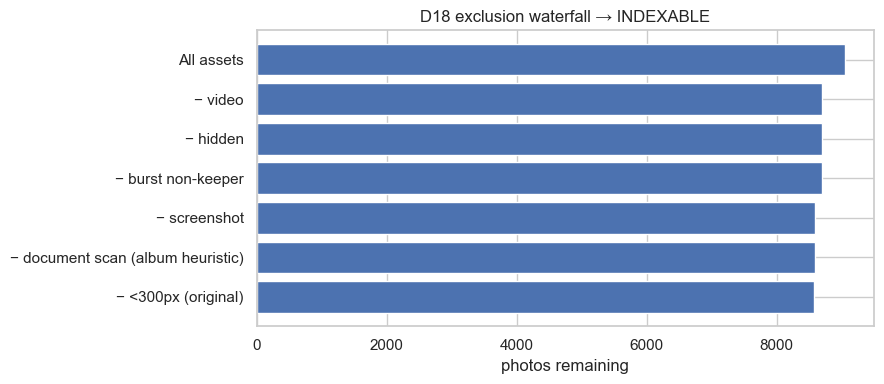

In [3]:
# ── S2. Identity + D18 exclusion waterfall ─────────────────────────────────
assert df["uuid"].is_unique, "UUID가 unique 가 아님 — 정체성 가정 위반!"
print(f"unique uuid: {df['uuid'].nunique():,} (== rows: {len(df):,}); 보정본도 1행: edited={int(df['edited'].sum()):,}")

steps, r = [], df
steps.append(("All assets", len(r)))
r = r[~r["ismovie"]];                          steps.append(("− video", len(r)))
r = r[~r["hidden"]];                           steps.append(("− hidden", len(r)))
r = r[~(r["burst"] & ~r["burst_selected"])];   steps.append(("− burst non-keeper", len(r)))
r = r[~r["screenshot"]];                        steps.append(("− screenshot", len(r)))
r = r[~r["in_doc_album"]];                      steps.append(("− document scan (album heuristic)", len(r)))
ow = r["orig_width"].fillna(r["width"]).fillna(0)
oh = r["orig_height"].fillna(r["height"]).fillna(0)
r = r[~((ow < MIN_DIM) | (oh < MIN_DIM))];      steps.append((f"− <{MIN_DIM}px (original)", len(r)))
indexable = r.copy()

wf = pd.DataFrame(steps, columns=["step", "remaining"])
wf["dropped"] = (wf["remaining"].shift(1) - wf["remaining"]).fillna(0).astype(int)
display(wf)
print(f"INDEXABLE: {len(indexable):,} / {len(df):,} = {len(indexable)/max(1,len(df)):.1%}  (Live Photo stills 유지)")

plt.figure(figsize=(9, 4))
plt.barh(wf["step"], wf["remaining"]); plt.gca().invert_yaxis()
plt.title("D18 exclusion waterfall → INDEXABLE"); plt.xlabel("photos remaining")
plt.tight_layout(); plt.show()

## S3 · GPS 커버리지
**검증: D14 Trip · D15 Daily Radius · reverse-geocode 의 상류 의존성.** 좌표가 없으면 trip/daily-radius/geocode 가
불가능하다. INDEXABLE 중 유효 lat/lng 비율과 **연도별 추이**(구형 사진일수록 낮을 것)를 본다.

GPS 커버리지 (INDEXABLE): 91.0%  (7,801/8,574)


,coverage,n
year,,
2012,0.000000,2
2014,0.000000,6
2015,0.000000,19
2016,0.803030,198
2017,0.851027,584
2018,0.778900,891
2019,0.674347,651
2020,0.895969,769
2021,0.976505,1362


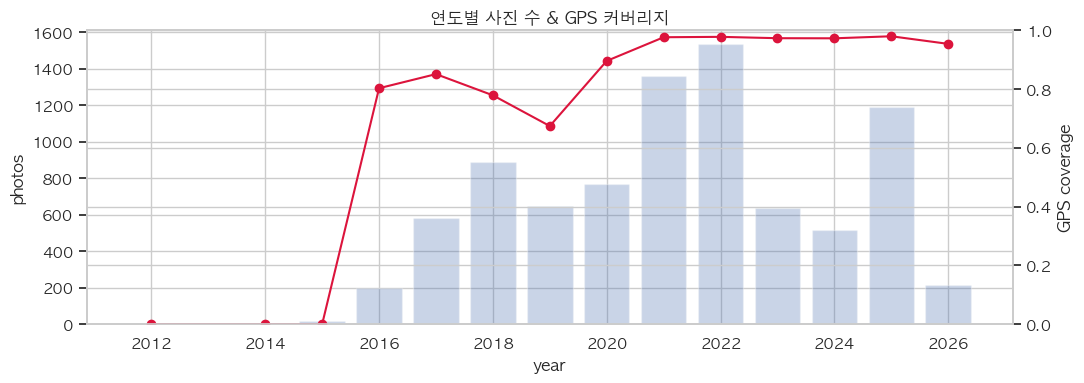

In [15]:
# ── S3. GPS coverage ───────────────────────────────────────────────────────
gps_cov = indexable["has_gps"].mean()
print(f"GPS 커버리지 (INDEXABLE): {gps_cov:.1%}  ({int(indexable['has_gps'].sum()):,}/{len(indexable):,})")

idx = indexable.dropna(subset=["date"]).copy()
idx["year"] = idx["date"].dt.year
by_year = idx.groupby("year")["has_gps"].agg(coverage="mean", n="size")
display(by_year.tail(15))

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(by_year.index, by_year["n"], alpha=0.3, label="photos")
ax2 = ax.twinx()
ax2.plot(by_year.index, by_year["coverage"], color="crimson", marker="o", label="GPS coverage")
ax2.set_ylim(0, 1); ax.set_xlabel("year"); ax.set_ylabel("photos"); ax2.set_ylabel("GPS coverage")
ax.set_title("연도별 사진 수 & GPS 커버리지"); fig.tight_layout(); plt.show()

## S4 · 타임스탬프 & 날짜 분포
**검증: D22 (recent-first 배치) · Trip 타임라인.** 유효 `taken_at` 비율, 1970/미래 sentinel 점검,
월별 히스토그램, 그리고 **최근 12개월 사진 수**(= recent-first 1차 배치 크기) 를 본다.

유효 taken_at: 100.0% | 미래 날짜: 0 | ≤1970(sentinel?): 0


/var/folders/lf/8x594xb50nng1wg8gz583qpc0000gn/T/ipykernel_1687/4056487136.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  dd["ym"] = dd["date"].dt.to_period("M").dt.to_timestamp()


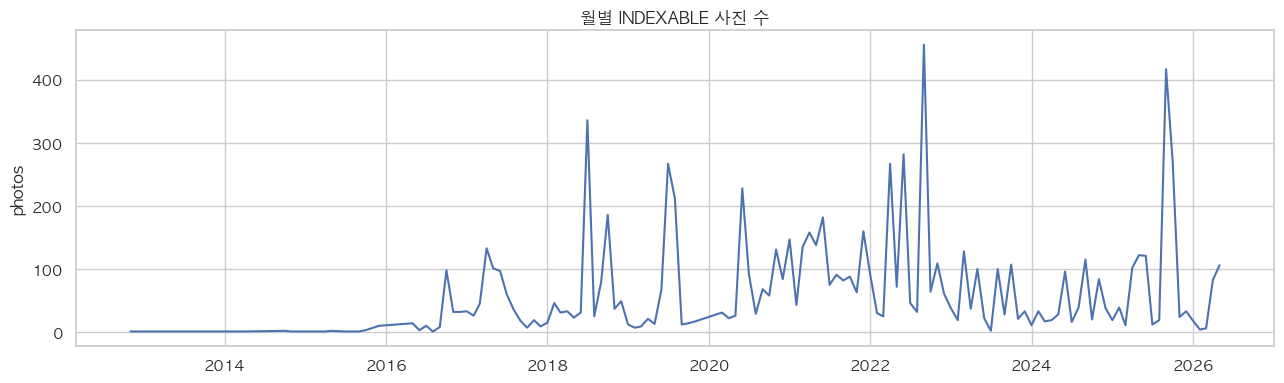

최근 12개월 사진 수 (≈ recent-first 1차 배치, D22): 1,113


In [16]:
# ── S4. Timestamps & date distribution ─────────────────────────────────────
d = indexable["date"]
valid_date = d.notna().mean()
now = pd.Timestamp.now(tz="UTC")
n_future = int((d > now).sum())
n_epoch  = int((d.dt.year <= 1970).sum())
print(f"유효 taken_at: {valid_date:.1%} | 미래 날짜: {n_future:,} | ≤1970(sentinel?): {n_epoch:,}")

dd = idx.copy()
dd["ym"] = dd["date"].dt.to_period("M").dt.to_timestamp()
monthly = dd.groupby("ym").size()
plt.figure(figsize=(13, 4)); plt.plot(monthly.index, monthly.values)
plt.title("월별 INDEXABLE 사진 수"); plt.ylabel("photos"); plt.tight_layout(); plt.show()

recent = int((d >= now - pd.DateOffset(years=1)).sum())
print(f"최근 12개월 사진 수 (≈ recent-first 1차 배치, D22): {recent:,}")

## S5 · Person 라벨 (named only)
**검증: D10.** Photos.app 에서 **named** 된 person 만 import 한다(`_UNKNOWN_PERSON` 제외). 사진당 named person 수
분포와 ≥1 비율, 상위 인물을 본다. 라벨이 희소하면 R2(인물) 질의 recall 이 제한된다.

≥1 named Person 비율: 12.3%


n_named_persons
0     7522
1     1049
2        3
3+       0
Name: photos, dtype: int64

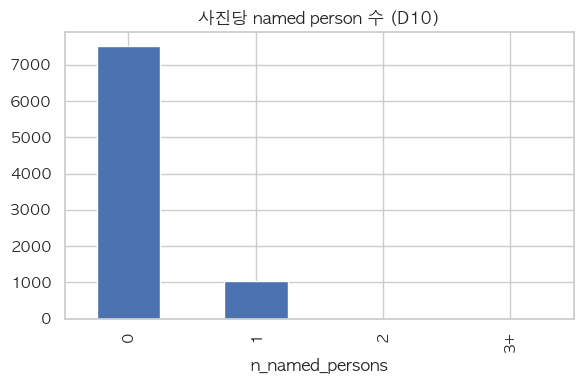

구별되는 named person 수: 1


우리웅디    1055
Name: photos, dtype: int64

In [17]:
# ── S5. Named-person labels ────────────────────────────────────────────────
nps = indexable["n_named_persons"]
print(f"≥1 named Person 비율: {(nps >= 1).mean():.1%}")
buckets = (pd.cut(nps, bins=[-1, 0, 1, 2, 10**9], labels=["0", "1", "2", "3+"])
           .value_counts().reindex(["0", "1", "2", "3+"]))
display(buckets.rename("photos"))
buckets.plot(kind="bar", figsize=(6, 4), title="사진당 named person 수 (D10)")
plt.tight_layout(); plt.show()

cnt = Counter()
for s in indexable["named_persons_json"]:
    try: cnt.update(json.loads(s))
    except Exception: pass
print(f"구별되는 named person 수: {len(cnt):,}")
display(pd.Series(dict(cnt.most_common(20)), name="photos"))

## S6 · 파일 포맷 & 해상도
**검증: D18 · 해싱.** UTI 분포(HEIC/JPEG/PNG — pillow-heif 필요성 정당화), 원본 해상도 분포, megapixel 히스토그램.
S2 의 `<300px` 필터가 제대로 걸렸는지 교차 확인.

uti
public.heic                    6645
public.jpeg                    1813
com.panasonic.rw2-raw-image      34
com.olympus.raw-image            29
public.png                       28
com.compuserve.gif               19
org.webmproject.webp              3
com.adobe.raw-image               1
public.tiff                       1
com.fuji.raw-image                1
Name: photos, dtype: int64

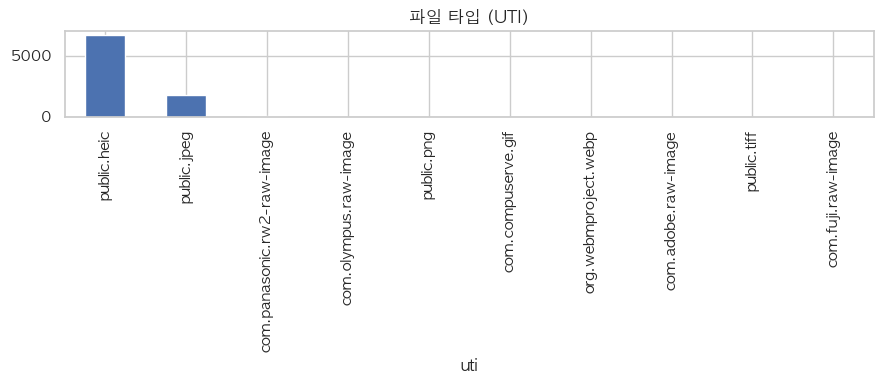

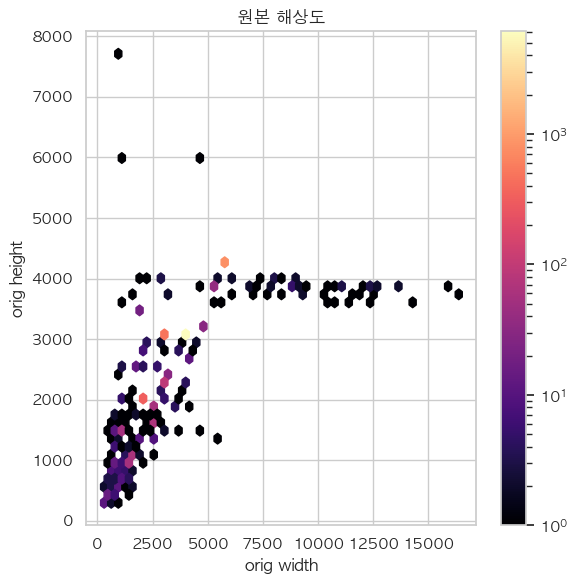

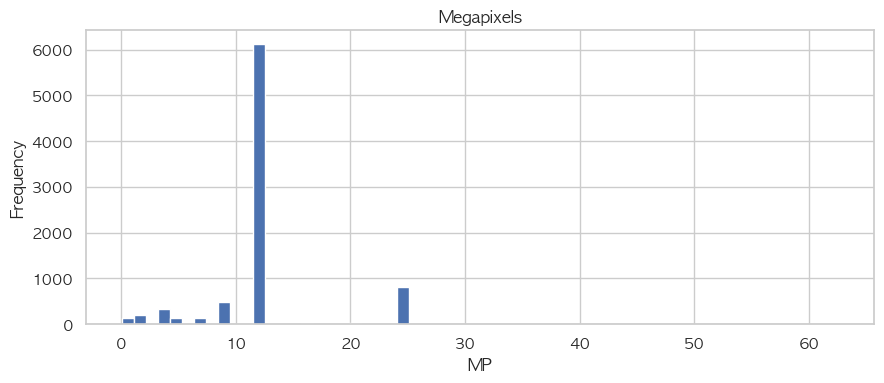

INDEXABLE 중 한 변 <300px (S2 후 ~0 이어야 함): 0


In [18]:
# ── S6. Formats & dimensions ───────────────────────────────────────────────
uti = indexable["uti"].value_counts()
display(uti.head(15).rename("photos"))
uti.head(10).plot(kind="bar", figsize=(9, 4), title="파일 타입 (UTI)"); plt.tight_layout(); plt.show()

dims = indexable.dropna(subset=["orig_width", "orig_height"])
if len(dims):
    plt.figure(figsize=(6, 6))
    plt.hexbin(dims["orig_width"], dims["orig_height"], gridsize=50, mincnt=1, bins="log", cmap="magma")
    plt.xlabel("orig width"); plt.ylabel("orig height"); plt.title("원본 해상도"); plt.colorbar()
    plt.tight_layout(); plt.show()
    (dims["orig_width"] * dims["orig_height"] / 1e6).plot(
        kind="hist", bins=60, figsize=(9, 4), title="Megapixels"); plt.xlabel("MP")
    plt.tight_layout(); plt.show()

small = int(((indexable["orig_width"].fillna(0) < MIN_DIM) |
             (indexable["orig_height"].fillna(0) < MIN_DIM)).sum())
print(f"INDEXABLE 중 한 변 <{MIN_DIM}px (S2 후 ~0 이어야 함): {small}")

## S9 · Daily Radius 타당성
**검증: D14 · D15.** 좌표는 저렴하므로 INDEXABLE 의 **모든 GPS 사진**을 쓴다. 산점도+hexbin 으로 밀도를 보고,
~5km 격자로 양자화해 **상위 밀집 셀**(집/직장/본가 후보)을 뽑는다. KDE 대신 양자화 격자를 쓰는 이유는 전 지구
좌표에서 bandwidth 문제 없이 견고하기 때문.

GPS 보유 INDEXABLE: 7,801


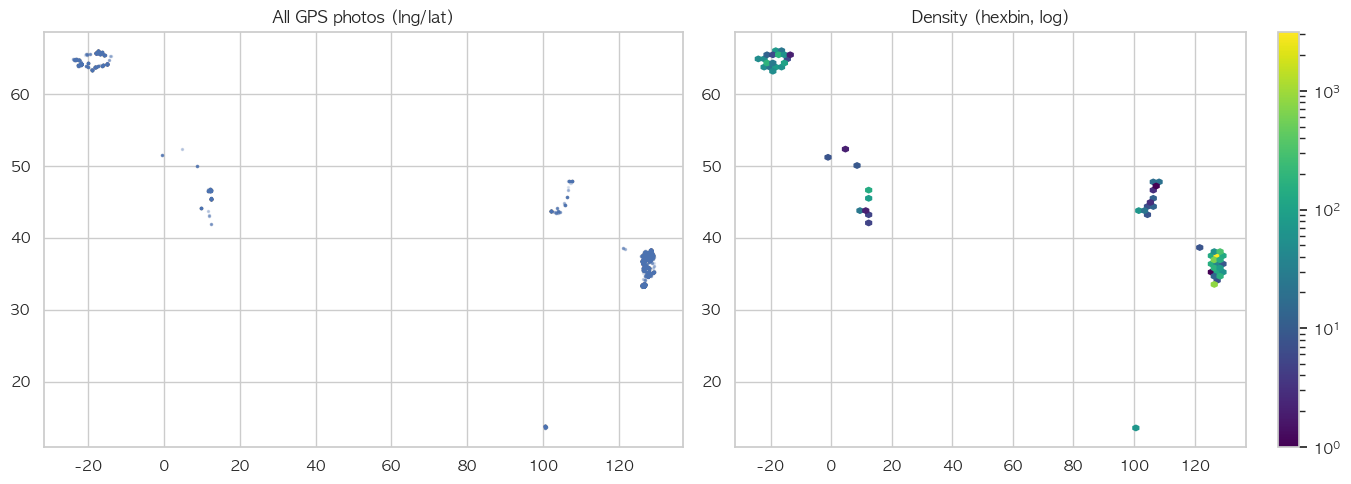

상위 밀집 셀 (~5km) — Daily Radius 후보(집/직장/본가):


,lat_q,lng_q,photos
0,37.50,127.05,730
1,37.55,126.85,443
2,37.65,126.65,414
3,37.55,126.95,327
4,37.55,127.05,204
5,64.15,-21.95,179
6,37.50,127.00,117
7,37.55,126.90,114
8,37.50,126.95,103
9,37.55,127.00,90


In [21]:
# ── S9. Daily Radius feasibility (density of GPS photos) ───────────────────
gps = indexable[indexable["has_gps"]].dropna(subset=["lat", "lng"]).copy()
print(f"GPS 보유 INDEXABLE: {len(gps):,}")

if len(gps):
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    ax[0].scatter(gps["lng"], gps["lat"], s=2, alpha=0.15); ax[0].set_title("All GPS photos (lng/lat)")
    hb = ax[1].hexbin(gps["lng"], gps["lat"], gridsize=80, mincnt=1, bins="log", cmap="viridis")
    ax[1].set_title("Density (hexbin, log)"); fig.colorbar(hb, ax=ax[1])
    plt.tight_layout(); plt.show()

    Q = 0.05  # ≈5km
    gps["lat_q"] = (gps["lat"] / Q).round() * Q
    gps["lng_q"] = (gps["lng"] / Q).round() * Q
    top_cells = gps.groupby(["lat_q", "lng_q"]).size().sort_values(ascending=False).head(10)
    print("상위 밀집 셀 (~5km) — Daily Radius 후보(집/직장/본가):")
    display(top_cells.rename("photos").reset_index())
else:
    top_cells = pd.Series(dtype=int)
    print("GPS 태그된 사진이 없어 S9/S10 생략.")

## S10 · Trip 타당성
**검증: D14 · D11.** S9 최대 밀집 셀을 잠정 "집"으로 두고 haversine 거리를 계산, **반경 밖에서 ≥24h 연속(미복귀)**
인 구간을 후보 Trip 으로 검출한다. 후보 수·예시 날짜를 보고, **GPS 없는 dated 사진**(위치로 trip 배정 불가) 수도 센다.
일상 반경(`RADIUS_KM`)은 설계상 미정이라 여기선 50km 로 잠정.

잠정 집 중심: (37.500, 127.050) · 반경 50km
후보 Trip (반경 밖 ≥24h 연속): 44


,start,end,n_photos,max_dist_km,duration_h
0,2016-10-08 04:06:12.188341+00:00,2016-10-11 12:15:22.337000+00:00,75,473.429265,80.152819
1,2017-03-31 22:04:59.216433+00:00,2017-04-02 08:58:22.540000+00:00,27,317.647302,34.889812
2,2017-04-08 07:40:30.766000+00:00,2017-04-12 12:54:09.481000+00:00,47,481.199415,101.227421
3,2017-05-20 07:23:44.234000+00:00,2017-05-21 11:50:16.054000+00:00,24,194.315999,28.442172
4,2017-07-08 01:51:27.566000+00:00,2017-07-09 07:32:26.840000+00:00,26,165.134011,29.683132
5,2018-04-07 04:38:26.171973+00:00,2018-04-08 05:11:24.296299+00:00,14,317.622774,24.549479
6,2018-05-12 05:25:04.380060+00:00,2018-05-13 06:14:43.828149+00:00,9,340.179589,24.827624
7,2018-07-14 06:48:25.702103+00:00,2018-07-21 13:14:51.825891+00:00,196,2202.266821,174.440590
8,2018-10-13 05:31:45.897674+00:00,2018-10-21 03:04:01.933069+00:00,94,3731.832185,189.537788
9,2018-12-29 04:25:26.439817+00:00,2018-12-30 07:04:08.741152+00:00,14,322.003989,26.645084


GPS 없는 dated 사진(위치로 Trip 배정 불가): 773 (9.0% of indexable)


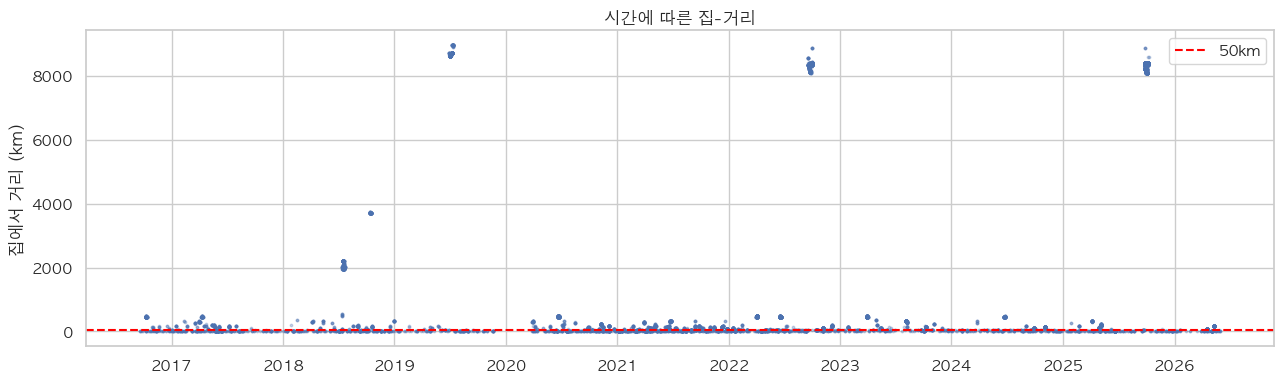

In [22]:
# ── S10. Trip feasibility (≥24h away from home) ────────────────────────────
if len(top_cells) == 0:
    print("GPS 밀도 없음 → Trip 타당성 생략.")
else:
    RADIUS_KM = 50  # 잠정 일상 반경 (feasibility probe)
    home_lat, home_lng = top_cells.index[0]
    print(f"잠정 집 중심: ({home_lat:.3f}, {home_lng:.3f}) · 반경 {RADIUS_KM}km")

    def haversine_km(lat1, lng1, lat2, lng2):
        R = 6371.0
        p1, p2 = np.radians(lat1), np.radians(lat2)
        dphi, dl = np.radians(lat2 - lat1), np.radians(lng2 - lng1)
        a = np.sin(dphi / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dl / 2) ** 2
        return 2 * R * np.arcsin(np.sqrt(a))

    g = gps.dropna(subset=["date"]).sort_values("date").copy()
    g["dist_home_km"] = haversine_km(g["lat"].values, g["lng"].values, home_lat, home_lng)
    g["away"] = g["dist_home_km"] > RADIUS_KM
    g["block"] = (g["away"] != g["away"].shift()).cumsum()
    runs = (g[g["away"]].groupby("block")
            .agg(start=("date", "min"), end=("date", "max"),
                 n_photos=("date", "size"), max_dist_km=("dist_home_km", "max")))
    runs["duration_h"] = (runs["end"] - runs["start"]).dt.total_seconds() / 3600
    trips = runs[runs["duration_h"] >= 24].sort_values("start")
    print(f"후보 Trip (반경 밖 ≥24h 연속): {len(trips)}")
    if len(trips): display(trips.reset_index(drop=True).head(20))

    no_gps_dated = indexable[(~indexable["has_gps"]) & indexable["date"].notna()]
    print(f"GPS 없는 dated 사진(위치로 Trip 배정 불가): {len(no_gps_dated):,} "
          f"({len(no_gps_dated)/max(1,len(indexable)):.1%} of indexable)")

    plt.figure(figsize=(13, 4))
    plt.scatter(g["date"], g["dist_home_km"], s=3, alpha=0.3)
    plt.axhline(RADIUS_KM, color="red", ls="--", label=f"{RADIUS_KM}km")
    plt.ylabel("집에서 거리 (km)"); plt.legend(); plt.title("시간에 따른 집-거리")
    plt.tight_layout(); plt.show()

## S11 · 로컬 Vision spike *(선택 — `RUN_VISION` 게이트)*
**검증: D2 · D19 · D20.** 샘플 일부를 로컬 멀티모달 모델로 영어 캡션 → 품질 눈으로 확인(D19). 캡션 + 한국어 쿼리를
임베딩해 cosine top-match 로 **multilingual 임베딩이 한국어 의도를 영어 캡션에 연결**하는지 본다(D20 caption-text leg).

> **Caveat.** PLAN 의 정확한 모델이 아닌 **설치된 대체 모델**(gemma4, qwen3-embedding)을 쓴다. 결과는 *지표적*이며,
> D20 의 **image-embedding leg 는 SigLIP/CLIP 도입(빌드 시점)까지 보류**. 무거우니 기본 `RUN_VISION=False`.

In [23]:
# ── S11. OPTIONAL local-vision spike ───────────────────────────────────────
if not RUN_VISION:
    print("RUN_VISION = False → vision spike 생략. S0 에서 True 로 바꾸고 이 셀 재실행.")
else:
    import ollama

    def _models():
        try: r = ollama.list()
        except Exception as e: return [], repr(e)
        ms = getattr(r, "models", None)
        if ms is None and isinstance(r, dict): ms = r.get("models", [])
        names = []
        for m in (ms or []):
            nm = getattr(m, "model", None)
            if nm is None and isinstance(m, dict): nm = m.get("model") or m.get("name")
            if nm: names.append(nm)
        return names, None

    avail, err = _models()
    print("Ollama 모델:", avail or err)

    sample_imgs = [f for f in sorted(SAMPLE_DIR.glob("*"))
                   if f.suffix.lower() in {".jpg", ".jpeg", ".png", ".heic", ".heif"}][:12]
    captions = []
    for f in sample_imgs:
        img_path = f
        if f.suffix.lower() in {".heic", ".heif"}:           # 멀티모달 모델은 보통 HEIC 미지원 → jpg 변환
            tmp = CACHE_DIR / (f.stem + ".jpg")
            with Image.open(f) as im: im.convert("RGB").save(tmp, "JPEG", quality=90)
            img_path = tmp
        try:
            resp = ollama.chat(model=CAP_MODEL, messages=[{
                "role": "user",
                "content": "Describe this photo in one concise English sentence.",
                "images": [str(img_path)]}])
            msg = getattr(resp, "message", None)
            text = getattr(msg, "content", None) if msg is not None else None
            if text is None and isinstance(resp, dict): text = resp["message"]["content"]
        except Exception as e:
            text = f"[caption error: {e!r}]"
        captions.append((f.name, (text or "").strip()))

    for name, cap in captions:
        try:
            with Image.open(SAMPLE_DIR / name) as im:
                im.thumbnail((220, 220)); display(im.convert("RGB"))
        except Exception:
            pass
        print(f"{name}: {cap}"); print()

    def _embed(texts):
        r = ollama.embed(model=EMBED_MODEL, input=texts)
        e = getattr(r, "embeddings", None)
        if e is None and isinstance(r, dict): e = r.get("embeddings")
        return np.array(e, dtype=float)

    caps_text = [c for _, c in captions if c and not c.startswith("[caption error")]
    queries = ["케이크 먹은 사진", "결혼식", "바닷가에서 찍은 사진", "눈 오는 날"]
    if caps_text:
        emb = _embed(caps_text + queries)
        ce, qe = emb[:len(caps_text)], emb[len(caps_text):]
        ce /= np.linalg.norm(ce, axis=1, keepdims=True)
        qe /= np.linalg.norm(qe, axis=1, keepdims=True)
        sim = qe @ ce.T
        print("── 한국어 쿼리 → 가장 가까운 영어 캡션 (D19/D20 bridge) ──")
        for qi, q in enumerate(queries):
            j = int(np.argmax(sim[qi]))
            print(f"[{q}] (cos={sim[qi][j]:.3f}) → {caps_text[j]}")

RUN_VISION = False → vision spike 생략. S0 에서 True 로 바꾸고 이 셀 재실행.


## S12 · Findings → PLAN.md 가정 함의
각 가정의 **측정값**을 모아 한눈에 본다. 마지막 VERDICT(VALIDATED / NEEDS-ADJUSTMENT / RISK)은 위 차트를
보고 **직접** 채운다 — 이 표가 구현 착수 전 의사결정의 근거다.

In [24]:
# ── S12. Findings summary ──────────────────────────────────────────────────
def _safe(fn, default="—"):
    try: return fn()
    except Exception: return default

rows = [
    ("GPS coverage (indexable)",      _safe(lambda: f"{gps_cov:.1%}"),                                                            "D14/D15",  "Trip·Daily Radius 의 상류 의존성"),
    ("Valid taken_at",                _safe(lambda: f"{valid_date:.1%}"),                                                          "D22",      "recent-first 배치·Trip 타임라인"),
    ("≥1 named Person",               _safe(lambda: f"{(indexable['n_named_persons']>=1).mean():.1%}"),                            "D10",      "R2 인물 질의 recall"),
    ("INDEXABLE / total",             _safe(lambda: f"{len(indexable):,}/{len(df):,} ({len(indexable)/len(df):.1%})"),            "D18",      "제외 규칙 적정성"),
    ("최근 12개월 사진",               _safe(lambda: f"{int((indexable['date']>=pd.Timestamp.now(tz='UTC')-pd.DateOffset(years=1)).sum()):,}"), "D22", "1차 배치 크기"),
    ("후보 Trip 수 (샘플 run)",        _safe(lambda: f"{len(trips)}"),                                                              "D14",      "Trip 검출 가능성"),
    ("dated-but-no-GPS (indexable)",  _safe(lambda: f"{int(((~indexable['has_gps']) & indexable['date'].notna()).sum()):,}"),    "D14",      "위치로 Trip 배정 불가분"),
    ("샘플 export",                    _safe(lambda: f"{int(mdf['exported'].sum())}/{len(mdf)}"),                                   "ADR-0002", "iCloud 미다운로드 skip"),
    ("near-dup 쌍 ≤cutoff",           _safe(lambda: f"{int((pdf['hamming']<=NEAR_DUP_CUTOFF).sum())}"),                            "D8",       "dHash cutoff 튜닝"),
]
fnd = pd.DataFrame(rows, columns=["assumption", "measured", "decision", "implication"])
fnd["VERDICT"] = ""
display(fnd)
print("위 차트를 보고 VERDICT 열(VALIDATED / NEEDS-ADJUSTMENT / RISK)을 직접 채우세요.")

,assumption,measured,decision,implication,VERDICT
0,GPS coverage (indexable),91.0%,D14/D15,Trip·Daily Radius 의 상류 의존성,
1,Valid taken_at,100.0%,D22,recent-first 배치·Trip 타임라인,
2,≥1 named Person,12.3%,D10,R2 인물 질의 recall,
3,INDEXABLE / total,"8,574/9,047 (94.8%)",D18,제외 규칙 적정성,
4,최근 12개월 사진,"1,113",D22,1차 배치 크기,
5,후보 Trip 수 (샘플 run),44,D14,Trip 검출 가능성,
6,dated-but-no-GPS (indexable),773,D14,위치로 Trip 배정 불가분,
7,샘플 export,93/93,ADR-0002,iCloud 미다운로드 skip,
8,near-dup 쌍 ≤cutoff,93,D8,dHash cutoff 튜닝,


위 차트를 보고 VERDICT 열(VALIDATED / NEEDS-ADJUSTMENT / RISK)을 직접 채우세요.
